Checking language type distribution in existing pretraining corpora

In [14]:
import os
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from huggingface_hub import HfApi, hf_hub_download

tqdm.pandas()

FONT_SIZES = {"small": 14, "medium": 18, "large": 24}

PLOT_PARAMS = {
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": FONT_SIZES.get("medium"),
    "axes.titlesize": FONT_SIZES.get("large"),
    "axes.labelsize": FONT_SIZES.get("large"),
    "xtick.labelsize": FONT_SIZES.get("large"),
    "ytick.labelsize": FONT_SIZES.get("large"),
    "legend.fontsize": FONT_SIZES.get("medium"),
    "figure.titlesize": FONT_SIZES.get("medium"),
    "text.usetex": True,
}

plt.rcParams.update(PLOT_PARAMS)

In [ ]:
def load_madlad(lang: str, split: str = "clean_docs") -> pd.DataFrame:
    """Load MADLAD-400 data for a given language code into a DataFrame.

    Args:
        lang: Language code (e.g. 'ceb', 'tgl', 'en').
        split: Which split to load — 'clean_docs', 'noisy_docs', or 'all'.
    """
    api = HfApi()
    files = api.list_repo_tree(
        "allenai/MADLAD-400",
        path_in_repo=f"data-v1p5/{lang}",
        repo_type="dataset",
    )

    local_dir = f"data/{lang}"
    os.makedirs(local_dir, exist_ok=True)

    paths = []
    for f in files:
        if not f.rfilename.endswith(".jsonl.gz"):
            continue
        if split != "all" and split not in f.rfilename:
            continue
        path = hf_hub_download(
            "allenai/MADLAD-400",
            filename=f.rfilename,
            repo_type="dataset",
            local_dir=local_dir,
        )
        paths.append(path)

    print(f"Downloaded {len(paths)} files for '{lang}'")
    return pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)

In [7]:
df = load_madlad("ceb", split="clean_docs")
df

Downloaded 10 files for 'ceb'


,text,timestamp,url
0,Ang Brand Africa nga nagpadayon sa pagsugat sa...,2021-09-24 00:24:28+00:00,https://ceb.eturbonews.com/165852/brand-africa...
1,"Gipalihok pinaagi sa Hiyas sa pagtugnaw, pagla...",2022-05-22 18:13:01+00:00,https://cleverplus.news/news/1409-ya_no_vayas_...
2,Ang Apple adunay labing kapuslan nga mga tinda...,2021-09-26 04:32:23+00:00,https://www.soydemac.com/ceb/apple-ang-labing-...
3,Hotels.com helps you to find the best hotel fo...,2021-11-27 03:08:03+00:00,https://sg.hotels.com/de700471/ugento-italy-ho...
4,Purohan batok COVID-19 | Banat\nPurohan batok ...,2020-11-28 12:00:41+00:00,https://www.philstar.com/banat/opinyon/2020/06...
...,...,...,...
66159,Giunsa nimo mahibal-an kung ang imong diyeta d...,2021-12-01 15:43:23+00:00,https://ceb.monemonkey.com/1-how-do-you-know-i...
66160,Mga Pagpaayo sa Buhok alang sa High School - D...,2021-10-28 01:46:05+00:00,https://www.bezzia.com/ceb/dali-ug-dali-nga-mg...
66161,Bisan kinsa nga masayud sa maayo Weather Addon...,2019-02-17 14:13:21+00:00,https://www.rikoooo.com/ceb/board?view=topic&i...
66162,Pagborda sa kompyuter alang sa mga kompyuter →...,2021-09-26 00:06:43+00:00,https://www.haftkomputerowy.com.pl/ceb/alang-s...


Before we do some fun stuff, might be nice to just learn more about the data

In [11]:
len(df["text"].iloc[0])

2805

100%|██████████| 66164/66164 [00:22<00:00, 2905.30it/s]


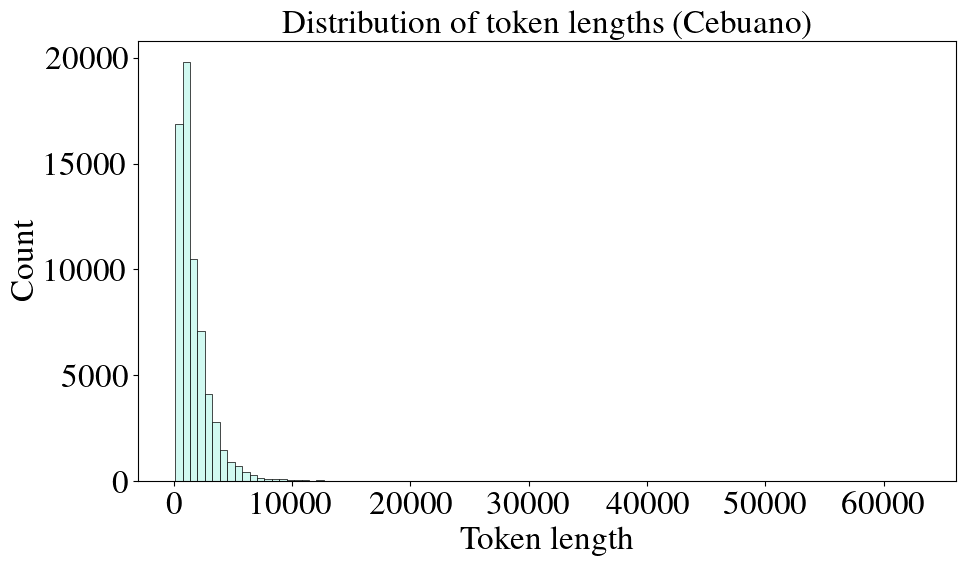

In [15]:
enc = tiktoken.get_encoding("cl100k_base")
df["token_length"] = df["text"].progress_apply(lambda x: len(enc.encode(x)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["token_length"], bins=100, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Token length")
ax.set_ylabel("Count")
ax.set_title("Distribution of token lengths (Cebuano)")
fig.tight_layout()
plt.show()

Ideally, I'd check each text and confirm which data type they have. But assuming I don't have any knowledge about the language, what can I do? Maybe...

- Check the URLs? Perhaps there's a way to cross-reference URLs to a certain domain.
- Use an LLM? Maybe something like [this work](https://arxiv.org/pdf/2502.10341). But how do you validate this?